# 03: Training
4-stage progressive training。Full 和 Lite 各跑一次。

**設定 `VARIANT` 後直接 Run All。**

| Stage | 啟用元件 | Epochs |
|-------|---------|--------|
| 1 | Spatial only | 40 |
| 2 | + Freq branch | 30 |
| 3 | + Cross attention | 30 |
| 4 | + Adaptive router | 20 |

In [6]:
# ============================================================
# CONFIG — 改這裡就好
# ============================================================
VARIANT    = 'lite'                       # 'full' 或 'lite'
DATA_ROOT  = '/workspace/zenodo_tmp'
OUTPUT_DIR = f'./checkpoints_{VARIANT}'

CONFIG = {
    'base_features':    32,
    'batch_size':       2,      # Full model 需要 2，Lite 可以用 4
    'target_size':      (128, 128, 128),
    'epochs_per_stage': [40, 30, 30, 20],
    'num_workers':      4,
    'lr':               1e-4,
    'random_seed':      42,
    'weight_decay':     1e-5,
    'use_amp':          True,   # 混合精度，省約 40% VRAM
}

# 從哪個 stage 開始（0-indexed）
# Stage 1 已跑完 → START_STAGE=1，全部重跑 → START_STAGE=0
START_STAGE = 0

N_TRAIN = 91; N_VAL = 19; N_TEST = 20

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'VARIANT={VARIANT}  batch_size={CONFIG["batch_size"]}  AMP={CONFIG["use_amp"]}')
print(f'START_STAGE={START_STAGE+1}  (stages {START_STAGE+1}~4 will run)')

VARIANT=lite  batch_size=2  AMP=True
START_STAGE=1  (stages 1~4 will run)


In [7]:
# ============================================================
# Cell 2: Load model definitions
# ============================================================
%run 02_model.ipynb


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip i

✅ Packages ready
Device: cuda
GPU: NVIDIA A40
VRAM: 47.7 GB
✅ MultiScaleWavelet3D, DoubleConv
✅ FrequencyBranchV4 (Full)
✅ FrequencyBranchLite
✅ CrossDomainAttention, AdaptiveRouter
AFS_DSN_V4 Full: 414.57M params
AFS_DSN_Lite: 27.41M params
✅ AFS_DSN_V4, AFS_DSN_Lite
✅ NasalSegDataset
✅ CombinedLoss, dice_coefficient, compute_dice_np
02_model.ipynb ready
  AFS_DSN_V4()   — full (~414M)
  AFS_DSN_Lite() — lite (~80M)
  NasalSegDataset(root)
  CombinedLoss() — CE + Dice


In [8]:
# ============================================================
# Cell 3: Dataset split (固定 seed=42，存 JSON)
# ============================================================
import json
import numpy as np
from torch.utils.data import DataLoader, Subset

np.random.seed(CONFIG['random_seed'])
torch.manual_seed(CONFIG['random_seed'])

full_dataset = NasalSegDataset(DATA_ROOT, target_size=CONFIG['target_size'])
indices = np.arange(len(full_dataset))
np.random.shuffle(indices)

train_idx = indices[:N_TRAIN].tolist()
val_idx   = indices[N_TRAIN:N_TRAIN+N_VAL].tolist()
test_idx  = indices[N_TRAIN+N_VAL:].tolist()

split_path = f'{OUTPUT_DIR}/split_indices.json'
with open(split_path, 'w') as f:
    json.dump({'train':train_idx,'val':val_idx,'test':test_idx,
               'seed':CONFIG['random_seed']}, f, indent=2)
print(f'Split saved: {split_path}')
print(f'  Train:{len(train_idx)} Val:{len(val_idx)} Test:{len(test_idx)}')

train_loader = DataLoader(Subset(full_dataset, train_idx),
                          batch_size=CONFIG['batch_size'], shuffle=True,
                          num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader   = DataLoader(Subset(full_dataset, val_idx),
                          batch_size=CONFIG['batch_size'], shuffle=False,
                          num_workers=CONFIG['num_workers'], pin_memory=True)

📊 Found 130 samples
Split saved: ./checkpoints_lite/split_indices.json
  Train:91 Val:19 Test:20


In [9]:
# ============================================================
# Cell 4: Training helpers — 加入 AMP 混合精度
# ============================================================
from tqdm import tqdm
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler(enabled=CONFIG['use_amp'])

def train_epoch(model, loader, optimizer, criterion, epoch):
    model.train()
    total_loss=0; total_dice=0
    pbar=tqdm(loader, desc=f'Epoch {epoch}')
    for images,masks in pbar:
        images,masks=images.to(device),masks.to(device)
        optimizer.zero_grad()
        with autocast(enabled=CONFIG['use_amp']):
            outputs=model(images)
            loss=criterion(outputs['output'],masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        dice=dice_coefficient(outputs['output'],masks)
        total_loss+=loss.item(); total_dice+=dice
        pbar.set_postfix({'loss':f'{loss.item():.4f}','dice':f'{dice:.4f}'})
    return total_loss/len(loader), total_dice/len(loader)

def validate(model, loader, criterion):
    model.eval(); total_loss=0; total_dice=0
    with torch.no_grad():
        for images,masks in tqdm(loader, desc='Validation'):
            images,masks=images.to(device),masks.to(device)
            with autocast(enabled=CONFIG['use_amp']):
                outputs=model(images)
                loss=criterion(outputs['output'],masks)
            total_loss+=loss.item()
            total_dice+=dice_coefficient(outputs['output'],masks)
    return total_loss/len(loader), total_dice/len(loader)

print('✅ train_epoch, validate ready (AMP enabled)')

✅ train_epoch, validate ready (AMP enabled)


/tmp/ipykernel_15471/601546610.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CONFIG['use_amp'])


In [10]:
# ============================================================
# Cell 5: 4-stage progressive training
# START_STAGE=1 → 跳過 Stage1，從 Stage2 開始
# ============================================================
import matplotlib.pyplot as plt

MODEL_CLS = AFS_DSN_V4 if VARIANT=='full' else AFS_DSN_Lite
criterion = CombinedLoss(num_classes=2)

stage_cfgs = [
    {'name':'Stage1_Spatial',   'freq':False,'attn':False,'router':False},
    {'name':'Stage2_FreqBranch','freq':True, 'attn':False,'router':False},
    {'name':'Stage3_CrossAttn', 'freq':True, 'attn':True, 'router':False},
    {'name':'Stage4_FullModel', 'freq':True, 'attn':True, 'router':True},
]

history = {}

# Stage1 已跑完 → 載入 checkpoint 作為起點
if START_STAGE > 0:
    ck_path = f'{OUTPUT_DIR}/{stage_cfgs[START_STAGE-1]["name"]}_best.pth'
    model = MODEL_CLS(
        num_classes=2, base_features=CONFIG['base_features'],
        **{k: stage_cfgs[START_STAGE-1][k] for k in ['freq','attn','router']}
        if False else dict(
            use_freq_branch=stage_cfgs[START_STAGE-1]['freq'],
            use_cross_attention=stage_cfgs[START_STAGE-1]['attn'],
            use_router=stage_cfgs[START_STAGE-1]['router'])
    ).to(device)
    ck = torch.load(ck_path, map_location=device)
    model.load_state_dict(ck['model'])
    print(f'✅ Loaded {ck_path}  (best_dice={ck["best_dice"]:.4f})')
    torch.cuda.empty_cache()
else:
    model = None

for stage_idx, scfg in enumerate(stage_cfgs):
    if stage_idx < START_STAGE:
        print(f'⏭️  Skipping {scfg["name"]} (already done)')
        continue

    epochs = CONFIG['epochs_per_stage'][stage_idx]
    print(f'\n{"="*60}')
    print(f'🚀 {scfg["name"]}  ({epochs} epochs)')
    print(f'{"="*60}')
    torch.cuda.empty_cache()

    new_model = MODEL_CLS(
        num_classes=2, base_features=CONFIG['base_features'],
        use_freq_branch=scfg['freq'],
        use_cross_attention=scfg['attn'],
        use_router=scfg['router']
    ).to(device)

    if model is not None:
        new_model.load_state_dict(model.state_dict(), strict=False)
        print('✅ Transferred weights from previous stage')
        del model; torch.cuda.empty_cache()
    model = new_model

    optimizer = optim.AdamW(model.parameters(),
                            lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_dice=0; train_losses=[]; val_dices=[]

    for epoch in range(1, epochs+1):
        tr_loss, tr_dice = train_epoch(model, train_loader, optimizer, criterion, epoch)
        val_loss, val_dice = validate(model, val_loader, criterion)
        scheduler.step()
        train_losses.append(tr_loss); val_dices.append(val_dice)

        if val_dice > best_dice:
            best_dice = val_dice
            save_checkpoint(model, optimizer, epoch, best_dice,
                            f'{OUTPUT_DIR}/{scfg["name"]}_best.pth', VARIANT)

        if epoch%5==0 or epoch==epochs:
            print(f'Ep {epoch:3d}/{epochs} | TrLoss {tr_loss:.4f} | '
                  f'TrDice {tr_dice:.4f} | ValDice {val_dice:.4f} | Best {best_dice:.4f}')

    history[scfg['name']] = {'train_loss':train_losses,'val_dice':val_dices,'best':best_dice}
    print(f'✅ {scfg["name"]} done. Best val Dice: {best_dice:.4f}')

print('\n🎉 All stages complete!')
for name,h in history.items(): print(f'  {name}: {h["best"]:.4f}')


🚀 Stage1_Spatial  (40 epochs)


Epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]/tmp/ipykernel_15471/601546610.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG['use_amp']):
Validation:   0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_15471/601546610.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG['use_amp']):
Validation: 100%|██████████| 10/10 [00:01<00:00,  5.26it/s]


💾 Saved: ./checkpoints_lite/Stage1_Spatial_best.pth  (epoch 1, dice 0.8919)


Validation: 100%|██████████| 10/10 [00:01<00:00,  6.39it/s]


💾 Saved: ./checkpoints_lite/Stage1_Spatial_best.pth  (epoch 2, dice 0.9149)


...

💾 Saved: ./checkpoints_lite/Stage4_FullModel_best.pth  (epoch 16, dice 0.9591)


Validation: 100%|██████████| 10/10 [00:06<00:00,  1.59it/s]


💾 Saved: ./checkpoints_lite/Stage4_FullModel_best.pth  (epoch 17, dice 0.9591)


Validation: 100%|██████████| 10/10 [00:06<00:00,  1.57it/s]


💾 Saved: ./checkpoints_lite/Stage4_FullModel_best.pth  (epoch 20, dice 0.9591)
Ep  20/20 | TrLoss 0.0220 | TrDice 0.9829 | ValDice 0.9591 | Best 0.9591
✅ Stage4_FullModel done. Best val Dice: 0.9591

🎉 All stages complete!
  Stage1_Spatial: 0.9493
  Stage2_FreqBranch: 0.9540
  Stage3_CrossAttn: 0.9573
  Stage4_FullModel: 0.9591


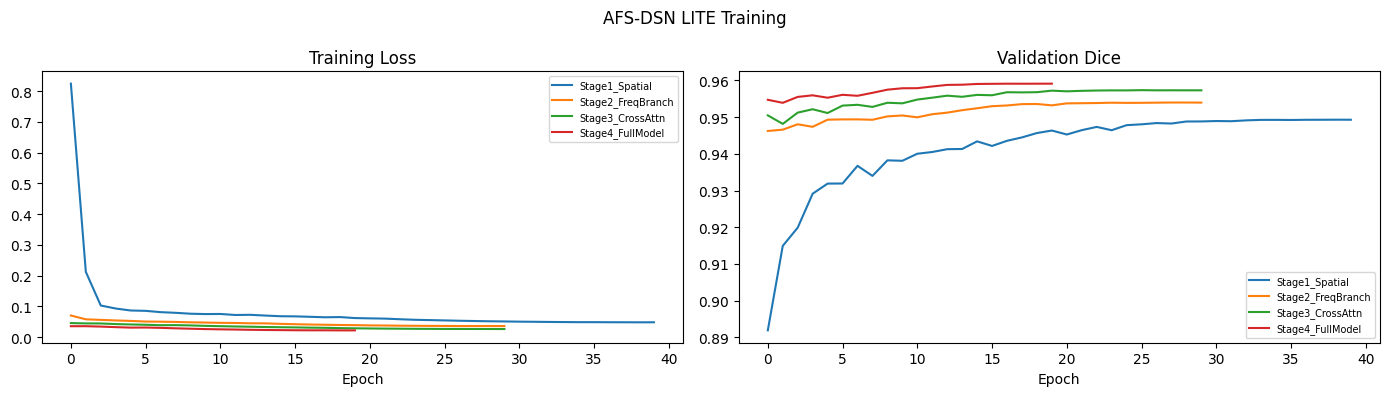

Saved: ./checkpoints_lite/training_curves.png


In [11]:
# ============================================================
# Cell 6: Training curves
# ============================================================
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(14,4))
colors=['#1f77b4','#ff7f0e','#2ca02c','#d62728']
for i,(name,h) in enumerate(history.items()):
    axes[0].plot(h['train_loss'],label=name,color=colors[i])
    axes[1].plot(h['val_dice'],  label=name,color=colors[i])
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=7)
axes[1].set_title('Validation Dice'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7)
plt.suptitle(f'AFS-DSN {VARIANT.upper()} Training',fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png',dpi=150)
plt.show()
print(f'Saved: {OUTPUT_DIR}/training_curves.png')

In [12]:
import json
with open('./checkpoints_full/split_indices.json') as f:
    s = json.load(f)
print(f"Train:{len(s['train'])} Val:{len(s['val'])} Test:{len(s['test'])}")

Train:91 Val:19 Test:20
